<a href="https://colab.research.google.com/github/dayisram/miRepomundosE/blob/main/Copia_de_Hackaton_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Limpieza y segmentacion de la muestra 9/07/2025**

In [ ]:
 # Activando libreria
import pandas as pd
import numpy as np

In [ ]:
# Ruta
# Los archivos estan en una carpeta compartida de Drive
from google.colab import drive
import os
ruta = "https://docs.google.com/spreadsheets/d/1HM80Ln3ATA59w-37vOqcmbQSoay4npnOkmxuAeDcwk0/gviz/tq?tqx=out:csv&sheet=users"

data = pd.read_csv(ruta)

In [ ]:
#Carga del dataset de base
print (data.shape) #ver cuantos registros y columnas tenemos
data.head()


(25000, 8)


,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14


In [ ]:
#buscamos datos nulos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            25000 non-null  int64  
 1   Name               25000 non-null  object 
 2   Age                25000 non-null  int64  
 3   Country            25000 non-null  object 
 4   Subscription_Type  25000 non-null  object 
 5   Watch_Time_Hours   25000 non-null  float64
 6   Favorite_Genre     25000 non-null  object 
 7   Last_Login         25000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.5+ MB


In [ ]:
usuarios_por_pais = data['Country'].value_counts()
print(usuarios_por_pais)

Country
UK           2592
Germany      2547
India        2505
USA          2503
Brazil       2503
Mexico       2493
Canada       2490
France       2473
Japan        2457
Australia    2437
Name: count, dtype: int64


# **Segmentando la muestra para centrarce en LATAM dentro de un rango etario de 13 a 60 años**

In [ ]:
# Segmentando la muestra para centrarce en LATAM y rango de 13 a 60 años de edad

# Drop the 'Last_Login' column from the original data DataFrame
data = data.drop('Last_Login', axis=1)

muestra = data[data['Country'].isin(['Brazil', 'Mexico'])]
print(muestra.shape)
print(muestra['Country'].value_counts())
muestra.head()

(4996, 7)
Country
Brazil    2503
Mexico    2493
Name: count, dtype: int64


,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre
9,10,Alex Davis,55,Mexico,Standard,696.66,Horror
18,19,Alex Johnson,63,Brazil,Premium,963.64,Action
25,26,Chris Johnson,26,Brazil,Premium,95.46,Sci-Fi
26,27,James Jones,17,Mexico,Standard,253.60,Documentary
28,29,Michael Johnson,59,Mexico,Basic,971.97,Drama


In [ ]:
# cambio el nombre de las columnas

muestra = muestra.rename(columns={'User_ID': 'ID_Usuario','Name':'Nombre', 'Age': 'Edad' ,'Country': 'País', 'Subscription_Type' :
                                  ' Subcripción' , 'Watch_Time_hour' :'Horas_de_visualización', 'Favorite_Genre':'Genero_favorito',
                                  'Last_Login':'Último ingreso'})
print(muestra.head())


    ID_Usuario           Nombre  Edad    País  Subcripción  Watch_Time_Hours  \
9           10       Alex Davis    55  Mexico     Standard            696.66   
18          19     Alex Johnson    63  Brazil      Premium            963.64   
25          26    Chris Johnson    26  Brazil      Premium             95.46   
26          27      James Jones    17  Mexico     Standard            253.60   
28          29  Michael Johnson    59  Mexico        Basic            971.97   

   Genero_favorito  
9           Horror  
18          Action  
25          Sci-Fi  
26     Documentary  
28           Drama  


In [ ]:
#
# Eliminar edades mayores a 80
muestra = muestra[muestra['Edad'] <= 80].copy()

# Reemplazar edades entre 60 y 80 con edades entre 13 and 60
muestra.loc[muestra['Edad'].between(60, 80, inclusive='both'), 'Edad'] = \
    np.random.randint(13, 61, size=muestra[muestra['Edad'].between(60, 80, inclusive='both')].shape[0])

print(muestra['Edad'].value_counts())

Edad
17    125
22    123
46    122
38    122
56    121
48    120
40    120
20    118
47    118
18    117
24    117
29    116
33    115
55    113
45    110
57    109
26    109
19    109
53    108
59    108
14    108
43    108
41    107
34    107
51    106
52    105
44    105
35    103
30    102
42    101
31    100
27    100
25    100
21     99
37     99
58     98
15     98
50     97
32     97
49     97
16     96
36     94
39     94
54     93
13     90
23     87
28     85
Name: count, dtype: int64


In [ ]:
# importando segunda tabla complementaria
from google.colab import drive
#ruta_excel = "logueos.xlsx"
ruta_excel = "https://docs.google.com/spreadsheets/d/1puQ6d-U-EOIG6oWtzReuQJMioMHHIxSD/gviz/tq?tqx=out:csv&sheet=Sheet1"
#data_excel = pd.read_excel(ruta_excel, engine='openpyxl')
data_excel = pd.read_csv(ruta_excel)


In [ ]:
from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# Sumamos las columnas para complementar los datos que faltan
logueos_cols = data_excel[['ID_Usuario', 'Logueos', 'Horas_sesion', 'Último ingreso']]

muestra = pd.merge(muestra, logueos_cols, on='ID_Usuario', how='left')
print("\nDataFrame 'muestra' después de la fusión:")
print(muestra.head())
print("\nInformación del DataFrame 'muestra' después de la fusión:")
muestra.info()


DataFrame 'muestra' después de la fusión:
   ID_Usuario           Nombre  Edad    País  Subcripción  Watch_Time_Hours  \
0          10       Alex Davis    55  Mexico     Standard            696.66   
1          19     Alex Johnson    48  Brazil      Premium            963.64   
2          26    Chris Johnson    26  Brazil      Premium             95.46   
3          27      James Jones    17  Mexico     Standard            253.60   
4          29  Michael Johnson    59  Mexico        Basic            971.97   

  Genero_favorito                                            Logueos  \
0          Horror  [datetime.datetime(2025, 6, 2, 15, 59), dateti...   
1          Action  [datetime.datetime(2025, 6, 2, 22, 34), dateti...   
2          Sci-Fi  [datetime.datetime(2025, 6, 19, 2, 9), datetim...   
3     Documentary  [datetime.datetime(2025, 6, 1, 21, 14), dateti...   
4           Drama  [datetime.datetime(2025, 6, 10, 16, 1), dateti...   

                                        Horas_ses

In [ ]:
muestra.head()

,ID_Usuario,Nombre,Edad,País,Subcripción,Watch_Time_Hours,Genero_favorito,Logueos,Horas_sesion,Último ingreso
0,10,Alex Davis,55,Mexico,Standard,696.66,Horror,"[datetime.datetime(2025, 6, 2, 15, 59), dateti...","[2.42, 2.12, 2.77, 1.75, 2.94, 2.95, 2.46, 1.54]",2025-06-07 16:23:01
1,19,Alex Johnson,48,Brazil,Premium,963.64,Action,"[datetime.datetime(2025, 6, 2, 22, 34), dateti...","[2.41, 4.15, 4.39, 4.65, 2.61, 4.23, 4.77]",2025-06-23 02:21:01
2,26,Chris Johnson,26,Brazil,Premium,95.46,Sci-Fi,"[datetime.datetime(2025, 6, 19, 2, 9), datetim...","[3.87, 4.7, 3.1, 4.67, 4.86, 2.64, 4.57, 4.48]",2025-07-21 13:29:09
3,27,James Jones,17,Mexico,Standard,253.60,Documentary,"[datetime.datetime(2025, 6, 1, 21, 14), dateti...","[2.35, 4.4, 4.81, 3.06, 4.86, 5.2, 2.07, 3.13,...",2025-06-01 19:50:52
4,29,Michael Johnson,59,Mexico,Basic,971.97,Drama,"[datetime.datetime(2025, 6, 10, 16, 1), dateti...","[2.58, 2.04, 1.73, 1.09, 2.34, 1.48, 2.13, 1.85]",2025-07-25 13:26:13


#**Algunos gráficos**



/tmp/ipython-input-71-3658986538.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=muestra, x='País', palette='pastel')


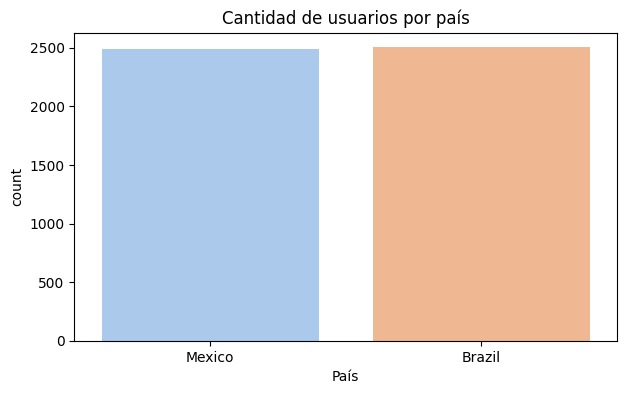

In [ ]:
#cantidad de usuarios por pais
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))
sns.countplot(data=muestra, x='País', palette='pastel')
plt.title('Cantidad de usuarios por país')
plt.show()

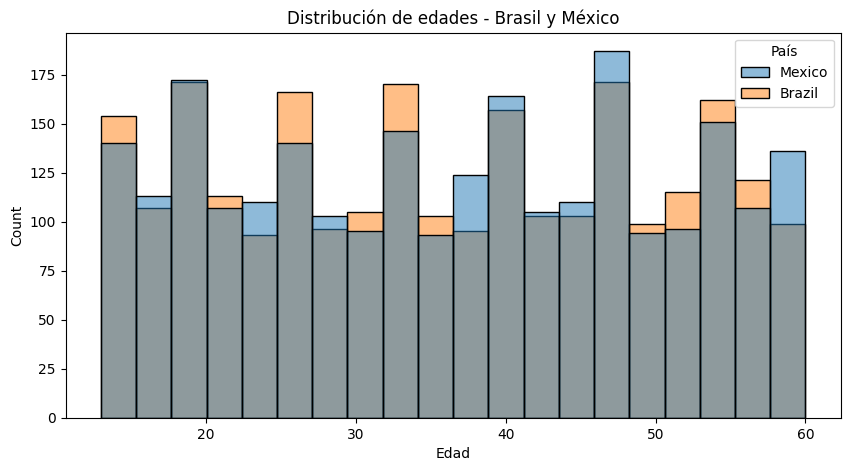

In [ ]:
#Edades por paises
plt.figure(figsize=(10,5))
sns.histplot(data=muestra, x='Edad', hue='País', bins=20)
plt.title('Distribución de edades - Brasil y México')
plt.show()

/tmp/ipython-input-54-3815664841.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=muestra, y='Genero_favorito', order=muestra['Genero_favorito'].value_counts().index, palette='viridis')


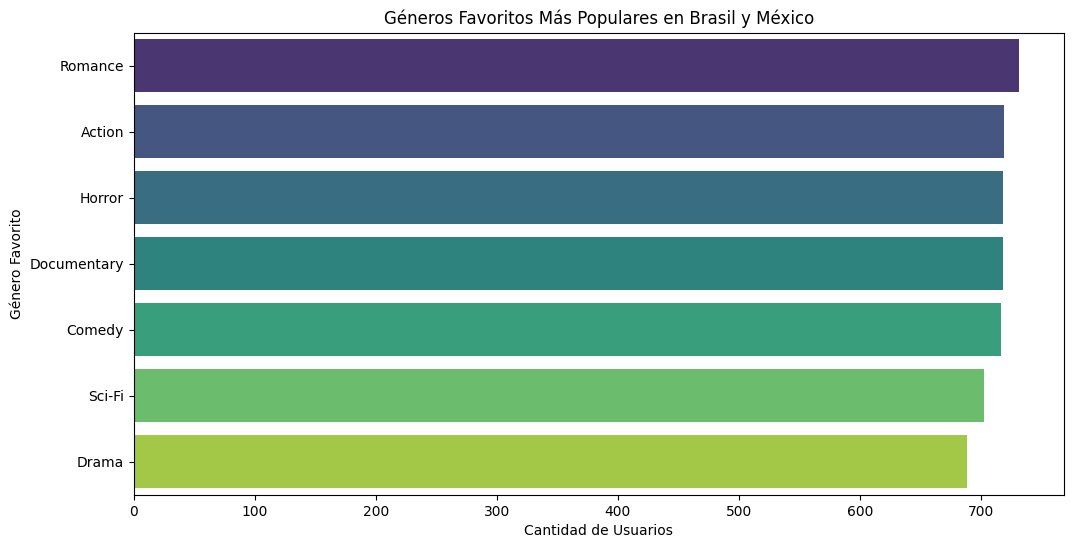

In [ ]:
# prompt: generos mas populares

import matplotlib.pyplot as plt
#generos mas populares
plt.figure(figsize=(12, 6))
sns.countplot(data=muestra, y='Genero_favorito', order=muestra['Genero_favorito'].value_counts().index, palette='viridis')
plt.title('Géneros Favoritos Más Populares en Brasil y México')
plt.xlabel('Cantidad de Usuarios')
plt.ylabel('Género Favorito')
plt.show()

Promedio de horas de visualización por género:
Genero_favorito
Romance        518.766598
Documentary    507.432577
Action         503.517608
Drama          499.618055
Comedy         491.708159
Sci-Fi         491.453698
Horror         488.508579
Name: Watch_Time_Hours, dtype: float64


/tmp/ipython-input-55-973440919.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=promedio_horas_por_genero.values, y=promedio_horas_por_genero.index, palette='magma')


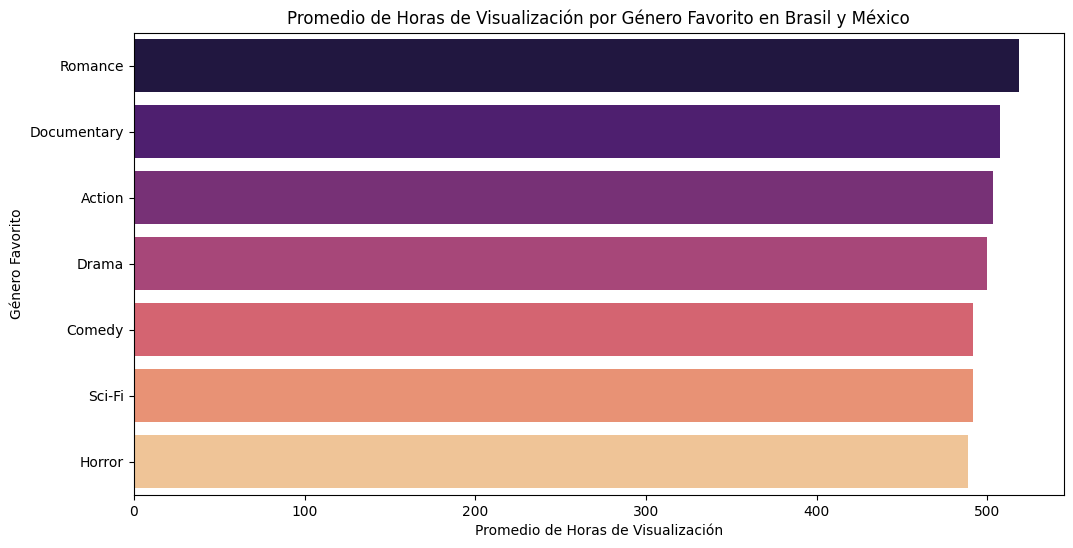

In [ ]:
# prompt: horas de visualizacion promedio por genero

import matplotlib.pyplot as plt
# Calcula el promedio de horas de visualización por género
promedio_horas_por_genero = muestra.groupby('Genero_favorito')['Watch_Time_Hours'].mean().sort_values(ascending=False)

print("Promedio de horas de visualización por género:")
print(promedio_horas_por_genero)

# Grafica el promedio de horas de visualización por género
plt.figure(figsize=(12, 6))
sns.barplot(x=promedio_horas_por_genero.values, y=promedio_horas_por_genero.index, palette='magma')
plt.title('Promedio de Horas de Visualización por Género Favorito en Brasil y México')
plt.xlabel('Promedio de Horas de Visualización')
plt.ylabel('Género Favorito')
plt.show()

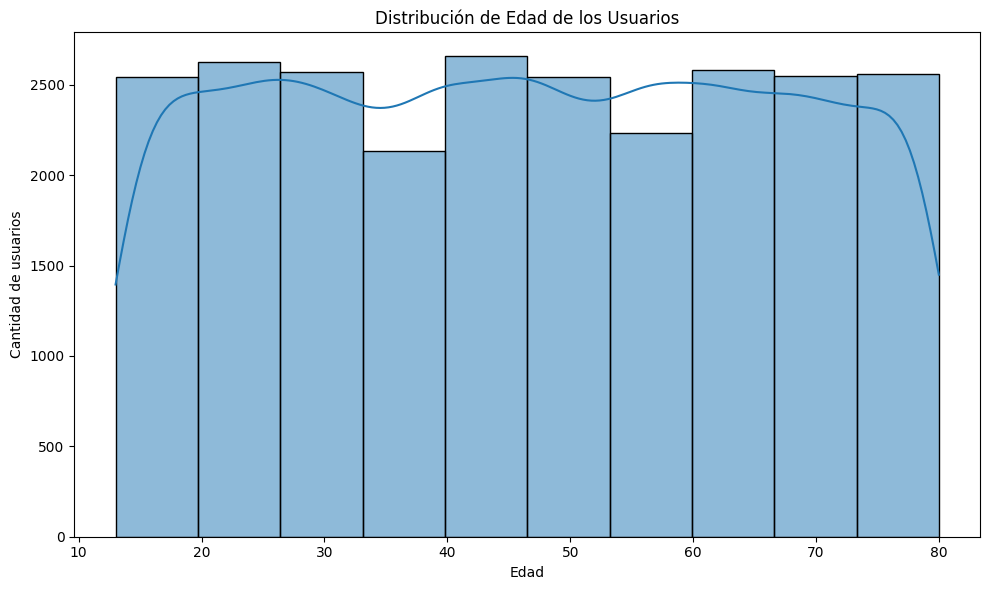

In [ ]:
#Distribucion por edad
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Age', bins=10, kde=True)
plt.title('Distribución de Edad de los Usuarios')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()



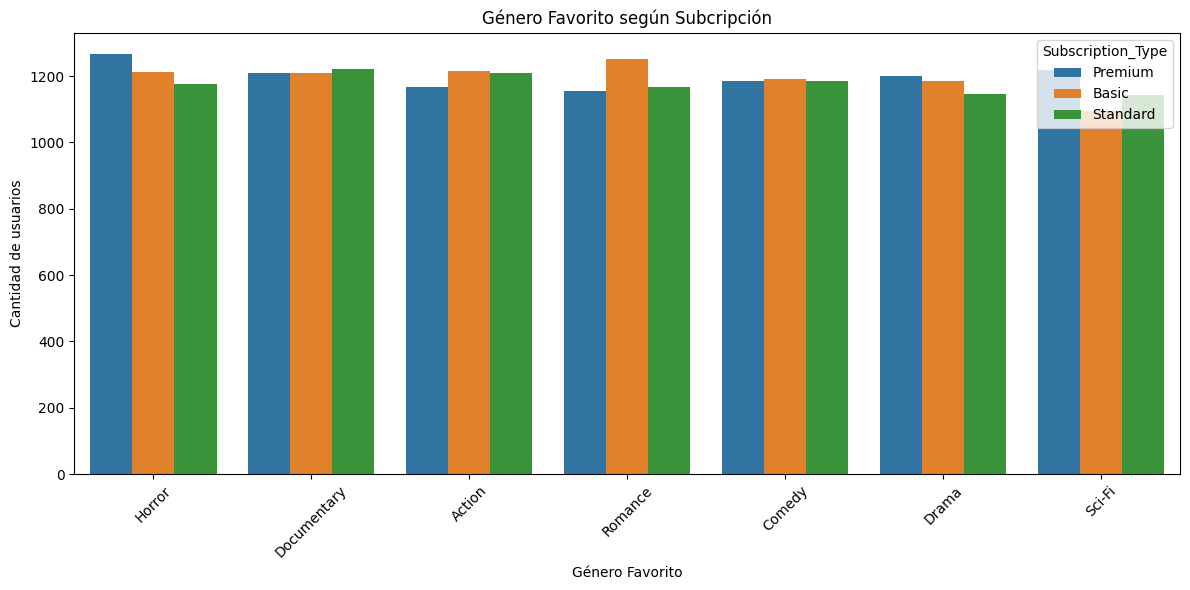

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='Favorite_Genre', hue='Subscription_Type', order=data['Favorite_Genre'].value_counts().index)
plt.title('Género Favorito según Subcripción')
plt.xlabel('Género Favorito')
plt.ylabel('Cantidad de usuarios')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
muestra.columns = muestra.columns.str.strip()

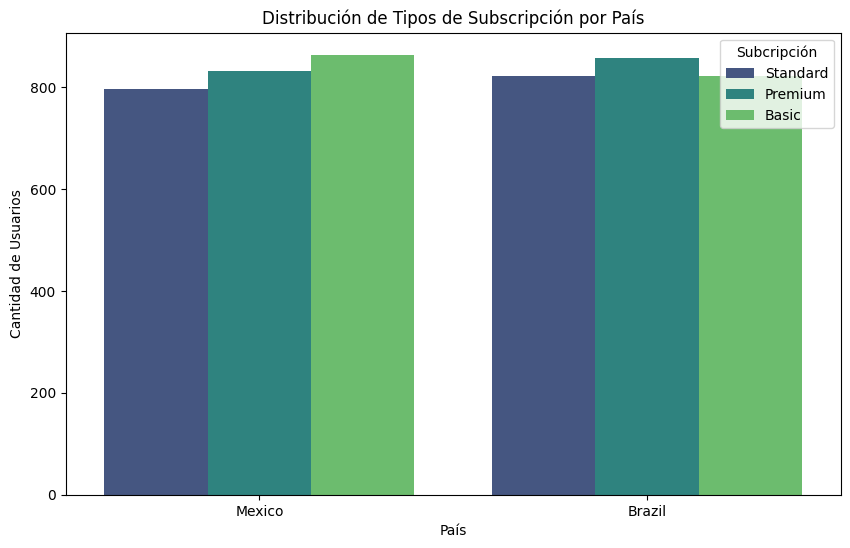


Cantidad de usuarios por país y tipo de subscripción:


Subcripción,Basic,Premium,Standard
País,,,
Brazil,823,858,822
Mexico,864,832,797


In [ ]:
# Analizar la distribución de tipos de suscripción por país en la muestra
plt.figure(figsize=(10, 6))
sns.countplot(data=muestra, x='País', hue='Subcripción', palette='viridis')
plt.title('Distribución de Tipos de Subscripción por País')
plt.xlabel('País')
plt.ylabel('Cantidad de Usuarios')
plt.show()

#  Tabla con el conteo de suscripciones por país
conteo_suscripciones_por_pais = muestra.groupby('País')['Subcripción'].value_counts().unstack(fill_value=0)
print("\nCantidad de usuarios por país y tipo de subscripción:")
conteo_suscripciones_por_pais

In [ ]:
#Random Forest
# Copia del dataset
df = muestra.copy()
df.columns = df.columns.str.strip()

# Import necessary libraries for modeling
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Codificar variables categóricas
le_pais = LabelEncoder()
le_sub = LabelEncoder()
df['País'] = le_pais.fit_transform(df['País'])
df['Subcripción'] = le_sub.fit_transform(df['Subcripción'])

# Variables predictoras y objetivo
X = df[['Edad', 'País', 'Subcripción', 'Watch_Time_Hours']]
y = df['Genero_favorito']

# División en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenamiento del modelo
modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X_train, y_train)

# Predicciones y evaluación
y_pred = modelo.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

Accuracy: 0.14543028685790527

Reporte de clasificación:
               precision    recall  f1-score   support

      Action       0.13      0.14      0.13       196
      Comedy       0.15      0.16      0.15       223
 Documentary       0.15      0.16      0.16       221
       Drama       0.15      0.15      0.15       212
      Horror       0.15      0.12      0.14       208
     Romance       0.15      0.14      0.14       225
      Sci-Fi       0.15      0.15      0.15       214

    accuracy                           0.15      1499
   macro avg       0.15      0.15      0.15      1499
weighted avg       0.15      0.15      0.15      1499



In [ ]:
# Predicciones y evaluación para KNN
from sklearn.neighbors import KNeighborsClassifier

modelo_knn = KNeighborsClassifier()
modelo_knn.fit(X_train, y_train)
y_pred_knn = modelo_knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


Accuracy: 0.12808539026017346
              precision    recall  f1-score   support

      Action       0.13      0.26      0.18       196
      Comedy       0.14      0.18      0.16       223
 Documentary       0.14      0.14      0.14       221
       Drama       0.09      0.07      0.08       212
      Horror       0.13      0.10      0.11       208
     Romance       0.15      0.11      0.12       225
      Sci-Fi       0.10      0.06      0.07       214

    accuracy                           0.13      1499
   macro avg       0.12      0.13      0.12      1499
weighted avg       0.12      0.13      0.12      1499



In [ ]:
print(df.columns.tolist())


['ID_Usuario', 'Nombre', 'Edad', 'País', 'Subcripción', 'Watch_Time_Hours', 'Genero_favorito', 'Logueos', 'Horas_sesion', 'Último ingreso']


# **Usuarios de prueba**

In [ ]:

# Codificamos país y suscripción para un nuevo usuario
pais_cod = le_pais.transform(['Mexico'])[0]
sub_cod = le_sub.transform(['Premium'])[0]

#Creamos el usuario nuevo
nuevo_usuario = pd.DataFrame([[25, pais_cod, sub_cod, 15.5]],
                             columns=['Edad', 'País', 'Subcripción', 'Watch_Time_Hours'])

# Hacemos la predicción
prediccion = modelo.predict(nuevo_usuario)

print("El género favorito predicho es:", prediccion[0])

El género favorito predicho es: Horror


In [ ]:
#Random Forest
# Copia del dataset
df = muestra.copy()

# Eliminar espacios adelante/atrás de los nombres de columnas
df.columns = df.columns.str.strip()

# Import necessary libraries for modeling
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Codificar variables categóricas
le_pais = LabelEncoder()
le_sub = LabelEncoder()
df['País'] = le_pais.fit_transform(df['País'])
df['Subcripción'] = le_sub.fit_transform(df['Subcripción'])

# Variables predictoras y objetivo
X = df[['Edad', 'País', 'Subcripción', 'Watch_Time_Hours']]
y = df['Genero_favorito']

# División en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenamiento del modelo
modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X_train, y_train)

# Predicciones y evaluación
y_pred = modelo.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

Accuracy: 0.14543028685790527

Reporte de clasificación:
               precision    recall  f1-score   support

      Action       0.13      0.14      0.13       196
      Comedy       0.15      0.16      0.15       223
 Documentary       0.15      0.16      0.16       221
       Drama       0.15      0.15      0.15       212
      Horror       0.15      0.12      0.14       208
     Romance       0.15      0.14      0.14       225
      Sci-Fi       0.15      0.15      0.15       214

    accuracy                           0.15      1499
   macro avg       0.15      0.15      0.15      1499
weighted avg       0.15      0.15      0.15      1499



In [ ]:
# Codificamos país y suscripción para un nuevo usuario
pais_cod = le_pais.transform(['Mexico'])[0]
sub_cod = le_sub.transform(['Premium'])[0]

#Creamos el usuario nuevo
nuevo_usuario = pd.DataFrame([[25, pais_cod, sub_cod, 15.5]],
                             columns=['Edad', 'País', 'Subcripción', 'Watch_Time_Hours'])

# Hacemos la predicción
prediccion = modelo.predict(nuevo_usuario)

print("El género favorito predicho es:", prediccion[0])

El género favorito predicho es: Horror


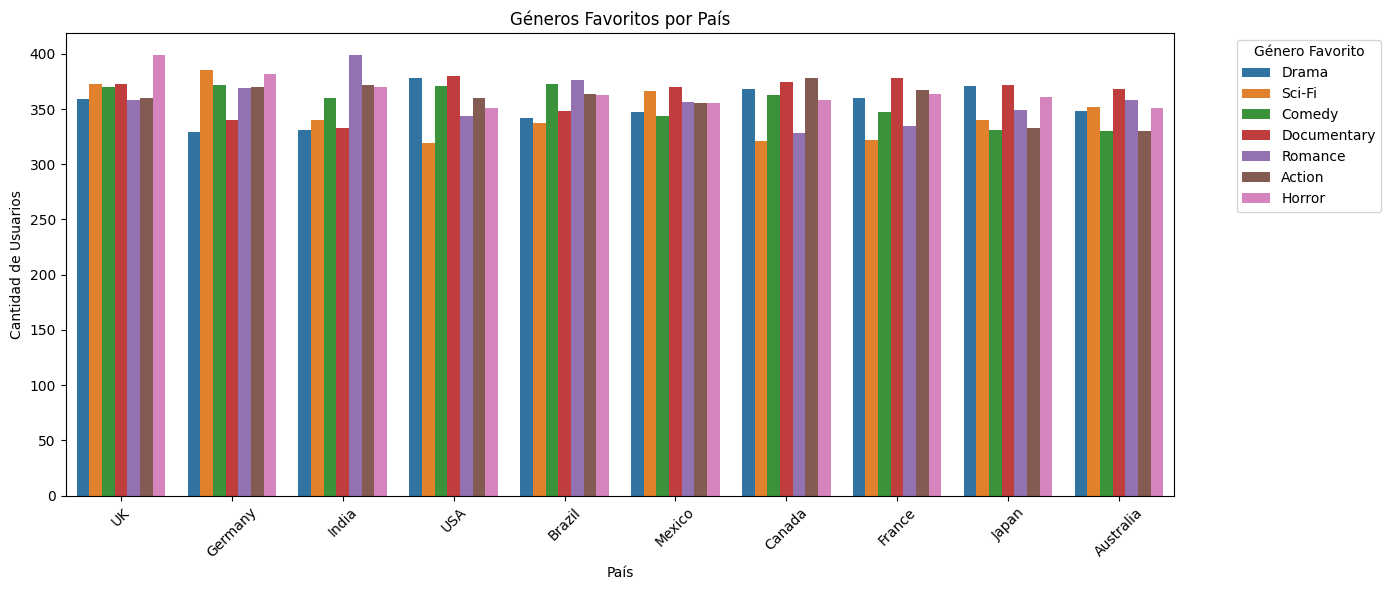

In [ ]:
plt.figure(figsize=(14, 6))
sns.countplot(data=data, x='Country', hue='Favorite_Genre', order=data['Country'].value_counts().index)
plt.title('Géneros Favoritos por País')
plt.xlabel('País')
plt.ylabel('Cantidad de Usuarios')
plt.legend(title='Género Favorito', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


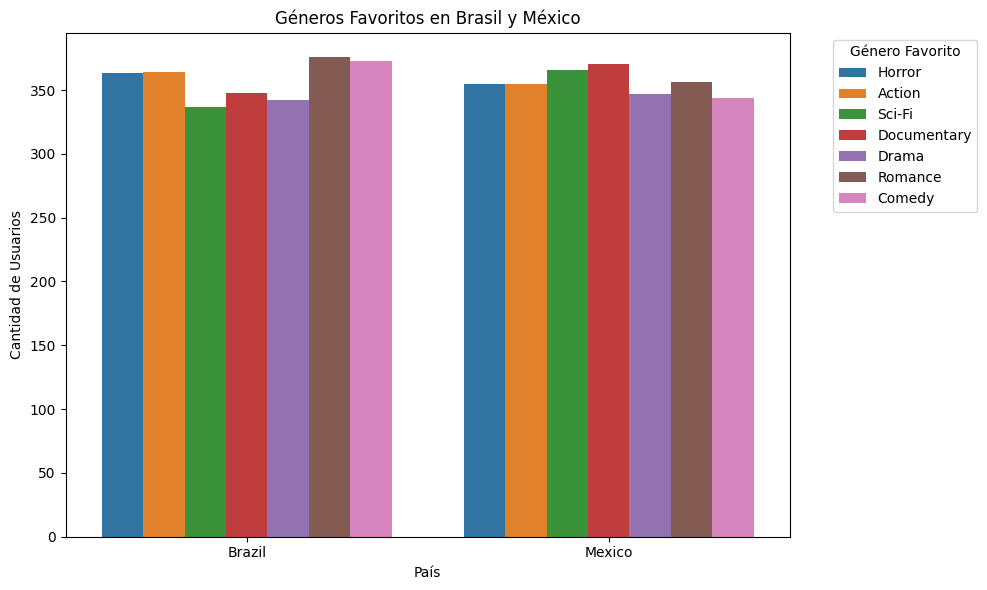

In [ ]:
# Filtrar solo Brasil y México
filtro_paises = data[data['Country'].isin(['Brazil', 'Mexico'])]

# Gráfico de barras agrupadas
plt.figure(figsize=(10, 6))
sns.countplot(data=filtro_paises, x='Country', hue='Favorite_Genre', order=['Brazil', 'Mexico'])
plt.title('Géneros Favoritos en Brasil y México')
plt.xlabel('País')
plt.ylabel('Cantidad de Usuarios')
plt.legend(title='Género Favorito', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
